In [149]:
import networkx as nx
import math
from random import choices, seed, randint
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [150]:
seed(randint(10**2, 10**7))
G = nx.MultiDiGraph()
G.add_node(0)
G.add_edge(0, 0)

0

![](edges_distrib.png)

![](edges_distrib_1.png)

In [151]:
def probability_in_node(G: nx.MultiDiGraph, node: int, delta_in: float):
    return (G.in_degree(node) + delta_in)/ (sum([t[1] for t in G.in_degree()]) + G.number_of_nodes() * delta_in)

def probability_out_node(G: nx.MultiDiGraph, node: int, delta_out: float):
    return (G.out_degree(node) + delta_out)/ (sum([t[1] for t in G.out_degree()]) + G.number_of_nodes() * delta_out)

In [152]:
def get_probabilities(n: int, c: float, to: int):
    # Пусть у нас 1 <= k <=100
    def poisson(n: int, k: int, c: float):
        def slow_var_f(k: int):
            return math.log(8*k)
        def lambda_f(k: int, c: float):
            return ((k ** c) * slow_var_f(k)) + 1
        return math.exp(-1 * lambda_f(n+1, c)) * (lambda_f(n+1, c) ** k-1) / math.factorial(k-1)

    return [poisson(n, k, c) for k in range(1, to)]

c = 0.2
K = get_probabilities(G.number_of_nodes(), c=c, to=100)
K


[0.048487113000798374,
 0.25139928566840725,
 0.5502799825216952,
 0.7756975679337669,
 0.8135682990362203,
 0.6813392643395448,
 0.475286502471756,
 0.2841540954029202,
 0.14864462887781998,
 0.06911770764740705,
 0.028924862379484505,
 0.011004249759591236,
 0.0038376112537992215,
 0.0012353766949253738,
 0.00036927775251430217,
 0.00010302524591255488,
 2.6946691599766973e-05,
 6.633432364419675e-06,
 1.5422244180089632e-06,
 3.3968451455984304e-07,
 7.107674452566827e-08,
 1.4164133386876295e-08,
 2.6943195470943615e-09,
 4.902335624122433e-10,
 8.548178329192708e-11,
 1.4309199535951777e-11,
 2.3031581821675978e-12,
 3.569782672502667e-13,
 5.335382016254007e-14,
 7.699265525580974e-15,
 1.0740136908231892e-15,
 1.449872786557789e-16,
 1.8961019936835925e-17,
 2.404526289667984e-18,
 2.95959569871496e-19,
 3.538719326067257e-20,
 4.113631566055617e-21,
 4.6527041983002095e-22,
 5.1239351048166024e-23,
 5.498203227885491e-24,
 5.752313829862048e-25,
 5.871384066494994e-26,
 5.85023

In [153]:
p = 0.7
c = 0.2
rounds = 10
def evolute(G, p, c, rounds):
    for _ in range(rounds):

        K = get_probabilities(G.number_of_nodes(), c=c, to=150)
        M = choices(population=list(range(1, 150)), weights=K)[0]

        for i in range(M):
            if choices(population=(0, 1), weights=(p, 1-p))[0] == 0:
                G.add_node(G.number_of_nodes())
                node_1 = G.number_of_nodes()

                node_2 = choices(population=list(range(G.number_of_nodes())), weights=[probability_in_node(G, n, 2) for n in range(G.number_of_nodes())])[0]

                G.add_edge(node_1, node_2)
            else:
                node_1 = choices(population=list(range(G.number_of_nodes())), weights=[probability_in_node(G, n, 2) for n in range(G.number_of_nodes())])[0]
                s2 = list(range(G.number_of_nodes())) 
                node_2 = choices(population=s2, weights=[probability_out_node(G, n, 2) for n in s2])[0]

                G.add_edge(node_1, node_2)

evolute(G, p, c, rounds)


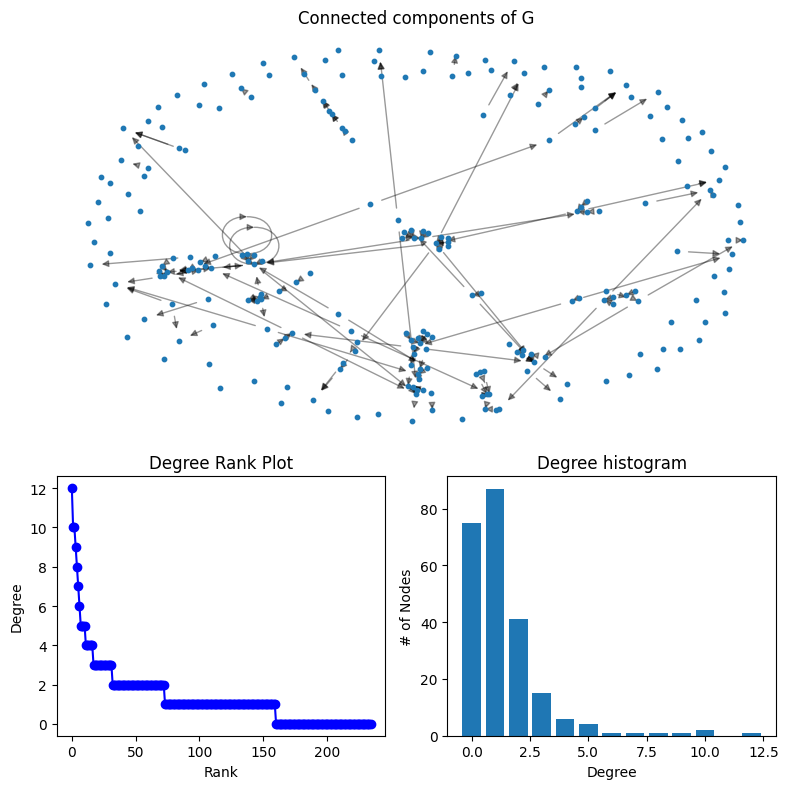

In [154]:
def draw_graph(G):
    degree_sequence = sorted((d for n, d in G.degree()), reverse=True)
    dmax = max(degree_sequence)

    fig = plt.figure("Degree of a random graph", figsize=(8, 8))
    # Create a gridspec for adding subplots of different sizes
    axgrid = fig.add_gridspec(5, 4)

    ax0 = fig.add_subplot(axgrid[0:3, :])
    pos = nx.spring_layout(G)
    nx.draw_networkx_nodes(G, pos, ax=ax0, node_size=10, margins=0)
    nx.draw_networkx_edges(G, pos, ax=ax0, alpha=0.4)
    ax0.set_title("Connected components of G")
    ax0.set_axis_off()

    ax1 = fig.add_subplot(axgrid[3:, :2])
    ax1.plot(degree_sequence, "b-", marker="o")
    ax1.set_title("Degree Rank Plot")
    ax1.set_ylabel("Degree")
    ax1.set_xlabel("Rank")

    ax2 = fig.add_subplot(axgrid[3:, 2:])
    ax2.bar(*np.unique(degree_sequence, return_counts=True))
    ax2.set_title("Degree histogram")
    ax2.set_xlabel("Degree")
    ax2.set_ylabel("# of Nodes")

    fig.tight_layout()
    plt.show()

draw_graph(G)

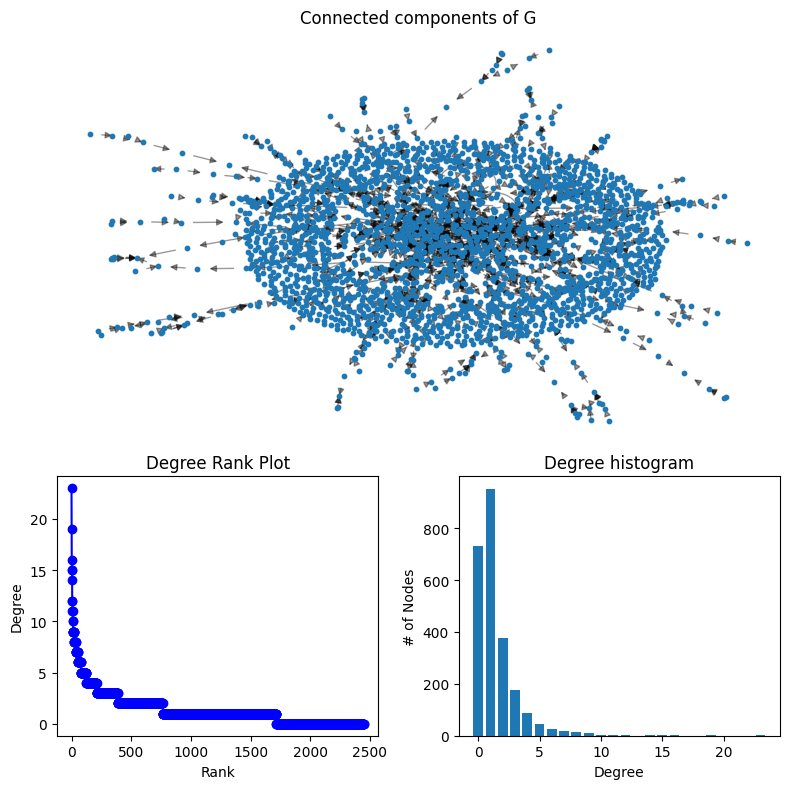

In [155]:
evolute(G, p, c, 40)

draw_graph(G)

In [156]:
evolute(G, p, c, 50)

draw_graph(G)

KeyboardInterrupt: 